In [21]:
from pathlib import Path
import os
import shutil
import zipfile

from urllib.request import urlretrieve

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [22]:
# ========================================================
# 下載資料集
# ========================================================
DATA_ROOT = Path("./data")
DATA_ROOT.mkdir(exist_ok=True)

TIN_URL = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
TIN_ZIP = DATA_ROOT / "tiny-imagenet-200.zip"
OUT_DIR = DATA_ROOT / "tiny-3class"

# class mapping: {wnid: (class_name, max_images)}
CLASS_INFO = {
    "n02099712": ("Labrador_Retriever", 400),
    "n02504458": ("African_Elephant", 400),
    "n01443537": ("Goldfish", 200),
}

# ========================================================
# Step 1 — Download tiny-imagenet zip
# ========================================================
if not OUT_DIR.exists():
    if not TIN_ZIP.exists():
        print("Downloading Tiny-ImageNet...")
        urlretrieve(TIN_URL, TIN_ZIP)
        print("Download complete.")
    else:
        print("Zip already exists.")
    
# ========================================================
# Step 2 — Selective extraction
# ========================================================

    print("\nExtracting ONLY selected categories...\n")

    with zipfile.ZipFile(TIN_ZIP, "r") as z:

        for wnid, (class_name, max_count) in CLASS_INFO.items():

            # output folder for images
            class_folder = OUT_DIR / class_name
            class_folder.mkdir(parents=True, exist_ok=True)

            prefix = f"tiny-imagenet-200/train/{wnid}/images/"
            img_files = sorted([
                f for f in z.namelist()
                if f.startswith(prefix) and f.lower().endswith(".jpeg")
            ])

            img_files = img_files[:max_count]  # limit number

            # extract limited images
            for f in img_files:
                z.extract(f, OUT_DIR)
                extracted = OUT_DIR / f
                # move to final location
                shutil.move(str(extracted), str(class_folder / Path(f).name))

            print(f"✔ {class_name}: {len(img_files)} images extracted")

            # remove intermediate tiny-imagenet-200 folder if exists
            temp_root = OUT_DIR / "tiny-imagenet-200"
            if temp_root.exists():
                shutil.rmtree(temp_root)
    print("\n Extraction complete!")
    print(f"Dataset ready at: {OUT_DIR}")

In [23]:
# ========================================================
# resized to 64 × 64
# ========================================================

# 1. 定義 transform：Resize + ToTensor + Normalize
#    Resize 到 64x64 並隨機翻轉、旋轉圖片等增加訓練強健性
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# 2. 用 ImageFolder 建立 Dataset
#   - root 底下每個子資料夾視為一個 class
#   - 我們現在是：tiny-3class/Labrador_Retriever/images/*.JPEG
#     ImageFolder 會遞迴往下找圖片，所以 OK
dataset = datasets.ImageFolder(
    root=str(OUT_DIR),
    transform=transform
)

In [24]:
# ===== Train/Val split =====

# 設定隨機種子，確保每次 split 一樣（可重現）
torch.manual_seed(42)

dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print("Total samples:", dataset_size)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

# 建立 DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 測試一個 batch
train_images, train_labels = next(iter(train_loader))
print("Train batch shape:", train_images.shape)
print("Train batch labels:", train_labels[:10])

Total samples: 1000
Train samples: 800
Val samples: 200
Train batch shape: torch.Size([32, 3, 64, 64])
Train batch labels: tensor([2, 2, 2, 0, 2, 2, 0, 0, 2, 2])


In [25]:
'''
CNN架構:捲積>池化>捲積>池化>捲積>池化>平坦層>全聯接層'''
class MyCNN(nn.Module):
    def __init__(
        self,
        k = 3,            # kernel size
        s = 1,            # stride
        f1 = 16, f2 = 32, f3 = 64     # filters
    ):
        super(MyCNN, self).__init__()

        # Conv layers
        self.conv1 = nn.Conv2d(3,  f1, kernel_size=k, stride=s, padding=k//2)
        self.conv2 = nn.Conv2d(f1, f2, kernel_size=k, stride=s, padding=k//2)
        self.conv3 = nn.Conv2d(f2, f3, kernel_size=k, stride=s, padding=k//2)

        # 最後 feature map 是 8x8（64→32→16→8）
        self.flat_dim = f3 * 8 * 8

        # Fully connected layers
        self.fc1 = nn.Linear(self.flat_dim, 128)   # 高階特徵
        self.fc2 = nn.Linear(128, 2)               # 2-node latent layer
        self.fc3 = nn.Linear(2, 3)                 # 分 3 類（Elephant/Golfish/Labrador）

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)

        # Flatten
        x = x.view(x.size(0), -1)

        # 128 維特徵
        x = F.relu(self.fc1(x))

        # 2 維 latent feature
        latent2d = self.fc2(x)

        # 最後分類
        out = self.fc3(latent2d)

        return out, latent2d


In [26]:
# =======================
# Training model
# =======================

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward
        outputs, _ = model(images)
        loss = criterion(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Record
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / len(train_loader), correct / total


def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    # 不需要計算梯度 → 加速 & 省顯存
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs, _ = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / len(val_loader), correct / total


# =======================
# Training entire model
# =======================
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=20):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

    return history


In [27]:
def plot_learning_curves(history):
    epochs = len(history["train_loss"])

    plt.figure(figsize=(14,5))

    # ----- Loss -----
    plt.subplot(1,2,1)
    plt.plot(range(epochs), history["train_loss"], label="Train Loss")
    plt.plot(range(epochs), history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.grid(True)

    # ----- Accuracy -----
    plt.subplot(1,2,2)
    plt.plot(range(epochs), history["train_acc"], label="Train Acc")
    plt.plot(range(epochs), history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()
    plt.grid(True)

    plt.show()


In [28]:
def plot_confusion_matrix(model, val_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs, _ = model(images)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()


In [29]:
# =======================
# 參數設定
# =======================
kernal = 5
stride = 1
filter1 = 32
filter2 = 64
filter3 = 128

Epoch [1/20] Train Loss: 1.1480, Train Acc: 34.62% | Val Loss: 0.9589, Val Acc: 52.50%
Epoch [2/20] Train Loss: 0.9958, Train Acc: 50.38% | Val Loss: 0.9555, Val Acc: 52.50%
Epoch [3/20] Train Loss: 0.9023, Train Acc: 61.00% | Val Loss: 0.7823, Val Acc: 62.50%
Epoch [4/20] Train Loss: 0.7567, Train Acc: 65.50% | Val Loss: 0.6667, Val Acc: 69.00%
Epoch [5/20] Train Loss: 0.6373, Train Acc: 70.62% | Val Loss: 0.6297, Val Acc: 72.00%
Epoch [6/20] Train Loss: 0.6022, Train Acc: 73.62% | Val Loss: 0.5291, Val Acc: 79.50%
Epoch [7/20] Train Loss: 0.5616, Train Acc: 77.00% | Val Loss: 0.5592, Val Acc: 71.50%
Epoch [8/20] Train Loss: 0.5381, Train Acc: 76.00% | Val Loss: 0.5756, Val Acc: 75.00%
Epoch [9/20] Train Loss: 0.5133, Train Acc: 79.12% | Val Loss: 0.5050, Val Acc: 78.00%
Epoch [10/20] Train Loss: 0.4789, Train Acc: 78.75% | Val Loss: 0.6007, Val Acc: 73.50%
Epoch [11/20] Train Loss: 0.4985, Train Acc: 77.88% | Val Loss: 0.4721, Val Acc: 81.50%
Epoch [12/20] Train Loss: 0.4494, Train A

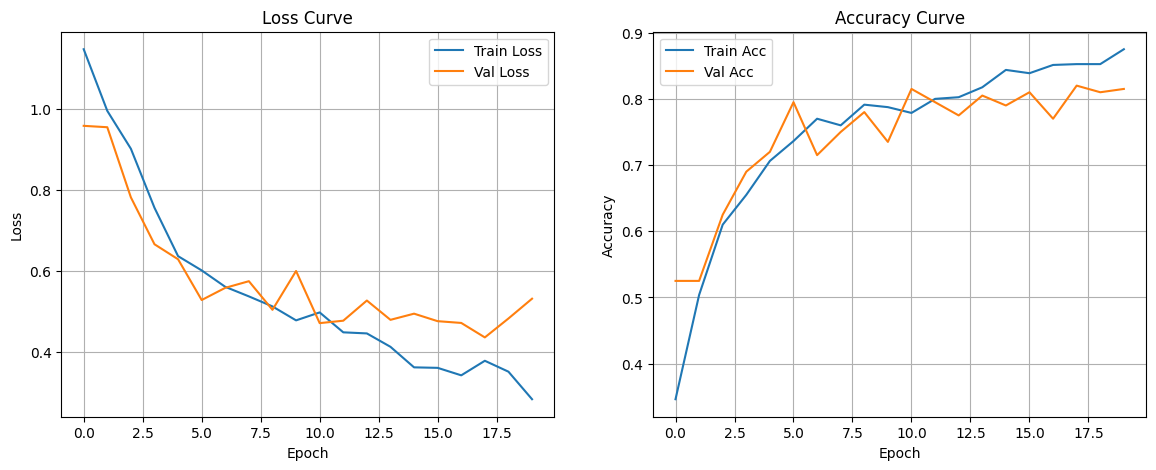

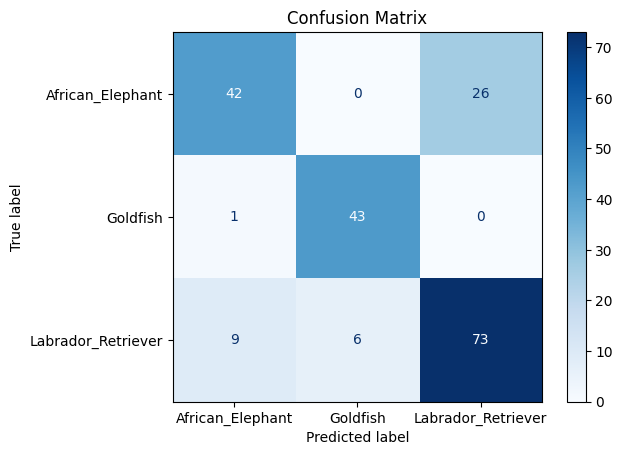

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MyCNN(
    k = kernal,
    s = stride,
    f1 = filter1,f2 = filter2,f3 = filter3
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20
)

plot_learning_curves(history)

plot_confusion_matrix(
    model,
    val_loader,
    device,
    class_names=list(dataset.class_to_idx.keys())
)
